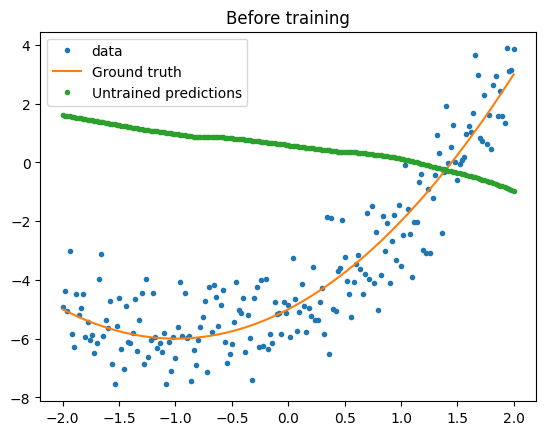

Paso 0: Mean squared error: 28.620
Paso 100: Mean squared error: 1.068
Paso 200: Mean squared error: 1.047
Paso 300: Mean squared error: 1.037
Paso 400: Mean squared error: 1.031
Paso 500: Mean squared error: 1.027
Paso 600: Mean squared error: 1.024
Paso 700: Mean squared error: 1.021
Paso 800: Mean squared error: 1.020
Paso 900: Mean squared error: 1.018
Paso 1000: Mean squared error: 1.017


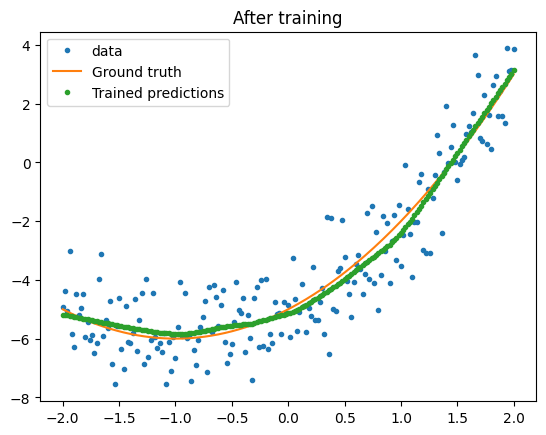

In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# 1. PREPARACIÓN DE DATOS

x = tf.linspace(-2, 2, 201)
x = tf.cast(x, tf.float32)

def f(x):
  y = x**2 + 2*x - 5
  return y

y = f(x) + tf.random.normal(shape=[201])

# 2. DEFINICIÓN DEL MODELO
class Model(tf.keras.Model):
  def __init__(self, units):
    super().__init__()
    self.dense1 = tf.keras.layers.Dense(units=units,
                                        activation=tf.nn.relu,
                                        kernel_initializer=tf.random.normal,
                                        bias_initializer=tf.random.normal)
    self.dense2 = tf.keras.layers.Dense(1)

  def call(self, x, training=True):
    x = x[:, tf.newaxis]
    x = self.dense1(x)
    x = self.dense2(x)
    return tf.squeeze(x, axis=1)

model = Model(64)

# 3. GRÁFICO ANTES DEL ENTRENAMIENTO
plt.plot(x.numpy(), y.numpy(), '.', label='data')
plt.plot(x.numpy(), f(x).numpy(), label='Ground truth')
plt.plot(x.numpy(), model(x).numpy(), '.', label='Untrained predictions')
plt.title('Before training')
plt.legend()
plt.show()

# 4. BUCLE DE ENTRENAMIENTO
variables = model.variables
optimizer = tf.optimizers.SGD(learning_rate=0.01)

for step in range(1001):
  with tf.GradientTape() as tape:
    prediction = model(x)
    error = (y - prediction)**2
    mean_error = tf.reduce_mean(error)

  gradient = tape.gradient(mean_error, variables)
  optimizer.apply_gradients(zip(gradient, variables))

  if step % 100 == 0:
    print(f'Paso {step}: Mean squared error: {mean_error.numpy():0.3f}')

# 5. GRÁFICO DESPUÉS DEL ENTRENAMIENTO
plt.plot(x.numpy(), y.numpy(), '.', label="data")
plt.plot(x.numpy(), f(x).numpy(), label='Ground truth')
plt.plot(x.numpy(), model(x).numpy(), '.', label='Trained predictions')
plt.title('After training')
plt.legend()
plt.show()